### Objectif: Nettoyer les données avant de créer de nouvelles variables.

### Importations des bibliothèques 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

print("Bibliothèques chargées.")


C:\Users\LENOVO\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Bibliothèques chargées.


#### Chargement du dataset

In [2]:
data = pd.read_excel("orbit_dataset.xlsx")
print(data.shape)

data.head()
print("Données ont été chargées avec succès")

(116720, 26)
Données ont été chargées avec succès


#### Informations generales

In [4]:
print("="*60)
print("INFORMATIONS GENERALES")
print("="*60)

print(f"Nombre de lignes   : {data.shape[0]}")
print(f"Nombre de colonnes : {data.shape[1]}")

display(data.head())

INFORMATIONS GENERALES
Nombre de lignes   : 116720
Nombre de colonnes : 26


,id_point,date_collecte,arrondissement,quartier,latitude,longitude,fillRate,fillRate_t_minus_1,fillRate_t_minus_2,delta_fillRate_24h,rolling_mean_3d,fillRate_target_t_plus_1,nb_signalements_citoyens,nb_plaintes,nb_precollecteurs_dispo,jours_depuis_derniere_collecte,capacity_m3,poids_kg,densite_population_hab_km2,jour_semaine_num,is_weekend,is_jour_marche,temperature_celsius,humidite_pct,statut_prevu,priorite_recommandee
0,CP001,2022-01-03,Douala 1er,Bali,4.001501,9.73807,49.55,33.98,12.98,15.58,32.17,6.00,0,0,2,2,7,933.30,18342,0,0,0,27.3,62.8,FAIBLE,BASSE
1,CP001,2022-01-04,Douala 1er,Bali,4.001501,9.73807,6.00,49.55,33.98,-43.56,29.84,21.43,0,0,1,0,7,107.60,18342,1,0,1,29.7,69.1,FAIBLE,BASSE
2,CP001,2022-01-05,Douala 1er,Bali,4.001501,9.73807,21.43,6.00,49.55,15.43,25.66,36.56,0,0,1,1,7,388.04,18342,2,0,0,28.6,67.0,FAIBLE,BASSE
3,CP001,2022-01-06,Douala 1er,Bali,4.001501,9.73807,36.56,21.43,6.00,15.13,21.33,52.21,0,0,3,2,7,673.95,18342,3,0,0,30.2,70.8,MODÉRÉ,MOYENNE
4,CP001,2022-01-07,Douala 1er,Bali,4.001501,9.73807,52.21,36.56,21.43,15.65,36.73,72.72,0,0,3,3,7,979.65,18342,4,0,0,28.4,61.3,PRESQUE SATURÉ,ÉLEVÉE


#### Strcuture

In [30]:
print("="*60)
print("STRUCTURE DU DATASET")
print("="*60)

data.info()

STRUCTURE DU DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116720 entries, 0 to 116719
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id_point                        116720 non-null  object 
 1   date_collecte                   116720 non-null  object 
 2   arrondissement                  116720 non-null  object 
 3   quartier                        116720 non-null  object 
 4   latitude                        116720 non-null  float64
 5   longitude                       116720 non-null  float64
 6   fillRate                        116720 non-null  float64
 7   fillRate_t_minus_1              116720 non-null  float64
 8   fillRate_t_minus_2              116720 non-null  float64
 9   delta_fillRate_24h              116720 non-null  float64
 10  rolling_mean_3d                 116720 non-null  float64
 11  fillRate_target_t_plus_1        116720 non-null  float64


#### Valeurs manquantes

In [31]:
missing = df.isnull().sum()

missing = missing[missing > 0]

print("Valeurs manquantes :")

display(missing)

Valeurs manquantes :


Series([], dtype: int64)

In [ ]:
#### Doublons

In [32]:
print("="*60)

print("DOUBLONS")

print("="*60)

print(data.duplicated().sum())

DOUBLONS
0


#### Statistiques 

In [33]:
display(data.describe().T)

,count,mean,std,min,25%,50%,75%,max
latitude,116720.0,4.045566,0.048222,3.940558,4.010506,4.044230,4.075389,4.179424
longitude,116720.0,9.702375,0.044429,9.570896,9.674735,9.698916,9.730496,9.800674
fillRate,116720.0,23.951267,18.388678,2.000000,10.230000,18.410000,33.490000,99.500000
fillRate_t_minus_1,116720.0,23.955521,18.390353,2.000000,10.230000,18.410000,33.510000,99.500000
fillRate_t_minus_2,116720.0,23.955589,18.388312,2.000000,10.230000,18.420000,33.510000,99.500000
delta_fillRate_24h,116720.0,-0.004248,19.309115,-97.380000,-4.242500,6.910000,11.130000,36.810000
rolling_mean_3d,116720.0,23.954139,13.841490,2.340000,13.540000,20.260000,31.190000,99.500000
fillRate_target_t_plus_1,116720.0,23.949255,18.385681,2.000000,10.230000,18.410000,33.490000,99.500000
nb_signalements_citoyens,116720.0,0.059236,0.293383,0.000000,0.000000,0.000000,0.000000,6.000000
nb_plaintes,116720.0,0.006083,0.083392,0.000000,0.000000,0.000000,0.000000,3.000000


#### Verification du Fill Rate

In [36]:
print(data["fillRate"].describe())

count    116720.000000
mean         23.951267
std          18.388678
min           2.000000
25%          10.230000
50%          18.410000
75%          33.490000
max          99.500000
Name: fillRate, dtype: float64


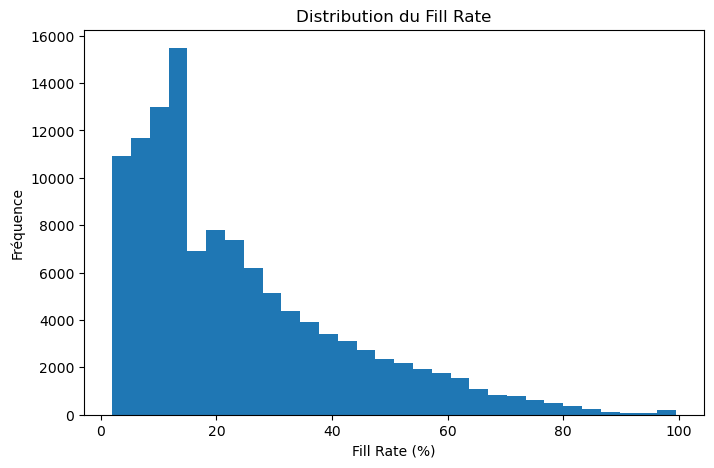

In [38]:
plt.figure(figsize=(8,5))

plt.hist(data["fillRate"], bins=30)

plt.title("Distribution du Fill Rate")

plt.xlabel("Fill Rate (%)")

plt.ylabel("Fréquence")

plt.show()

#### Verification des dates

In [39]:
data["date_collecte"] = pd.to_datetime(df["date_collecte"])

print("Début :", data["date_collecte"].min())

print("Fin   :", data["date_collecte"].max())

Début : 2020-01-01 00:00:00
Fin   : 2024-12-31 00:00:00


#### Conclusion

In [40]:
print("="*60)
print("PREPARATION TERMINE")
print("="*60)

print("✔ Dataset chargé")

print("✔ Structure vérifiée")

print("✔ Dates vérifiées")

print("✔ Fill Rate contrôlé")

print("Le dataset est prêt pour le prétraitement.")

PREPARATION TERMINE
✔ Dataset chargé
✔ Structure vérifiée
✔ Dates vérifiées
✔ Fill Rate contrôlé
Le dataset est prêt pour le prétraitement.
